# Running your first stats

So now that we read and cleaned the data set, we can go on to address our research questions. As a reminder, we want to:
* assess whether hearing thresholds are predictive to brain age gaps
* assess hearing hearing thresholds are related to depressive affect.

Let's read the data first.

In [1]:
if (!require(conflicted)) install.packages("conflicted")
library(conflicted)

library(tidyverse)

# Load the saved R data (creates `selected_data`)
load("./data/selected_data.Rdata")

# Quick check
head(selected_data)

Loading required package: conflicted

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     


age,sex,education_var,stress,rated_health,depression,brain_age,hearing_avg,BAG
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
68,1,9,20,8,0,66.3543,14.1666667,1.6457
58,1,5,23,8,0,49.5967,20.8333333,8.4033
51,2,9,30,7,0,44.3794,4.1666667,6.6206
33,1,5,22,8,0,25.7643,5.0000000,7.2357
49,1,9,16,7,0,56.1074,10.0000000,-7.1074
31,2,8,18,9,0,33.5318,0.8333333,-2.5318


We can do a quick visualization, relating the variables in our research questions.

`geom_smooth()` using formula = 'y ~ x'


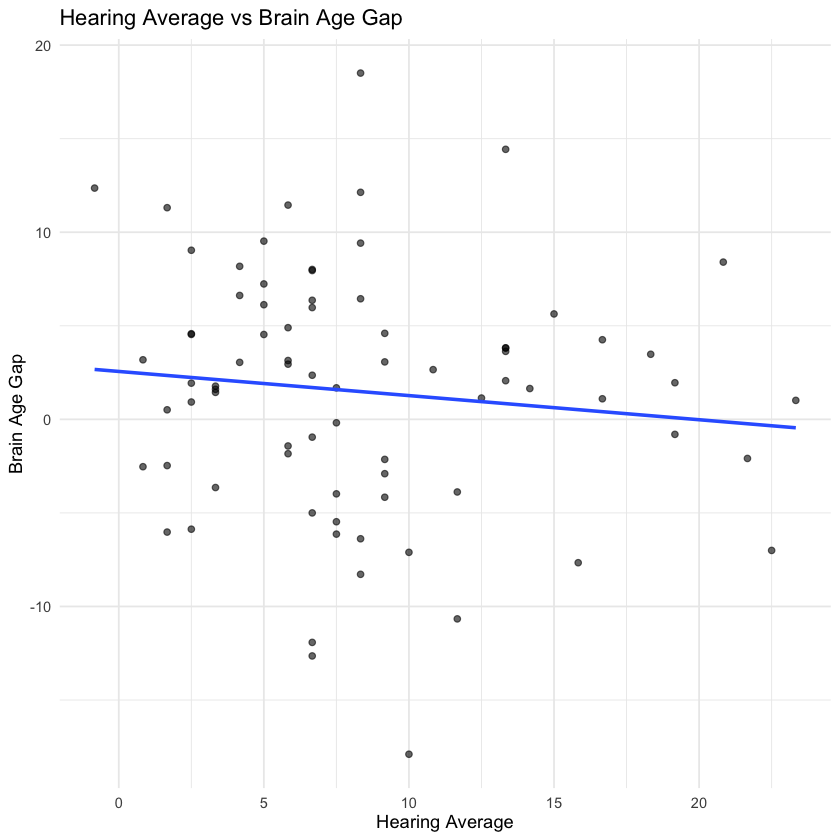

In [2]:
ggplot(selected_data, aes(x = hearing_avg, y = BAG)) +
    geom_point(alpha = 0.6) +
    geom_smooth(method = "lm", se = FALSE) +
    labs(
        x = "Hearing Average",
        y = "Brain Age Gap",
        title = "Hearing Average vs Brain Age Gap"
    ) +
    theme_minimal()

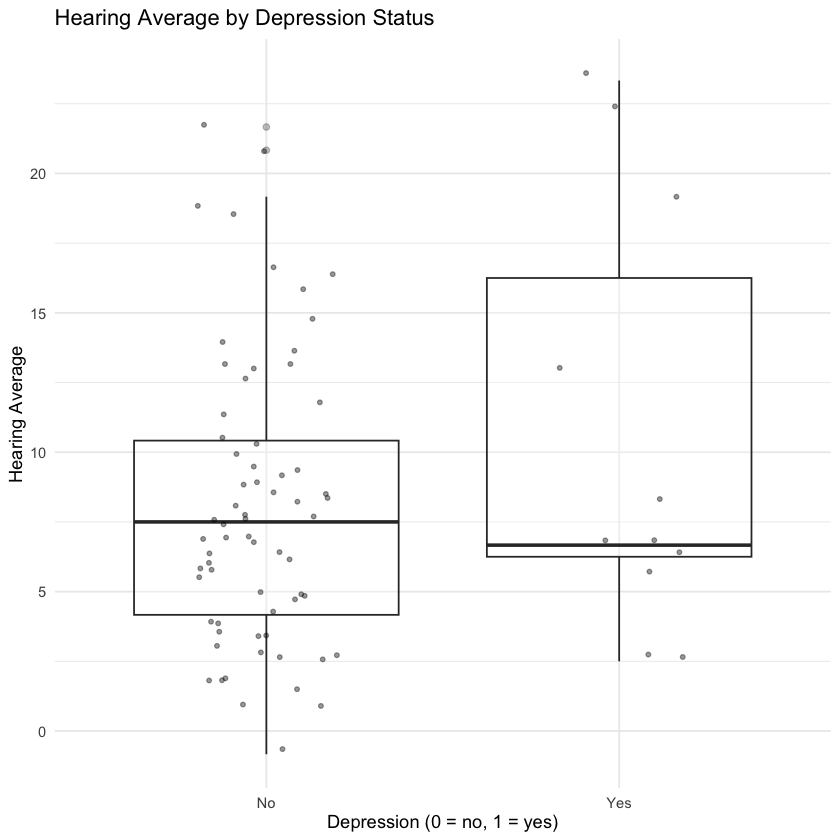

In [3]:
ggplot(selected_data, aes(x = factor(depression), y = hearing_avg)) +
    geom_boxplot(alpha = 0.3) +
    geom_jitter(width = 0.2, alpha = 0.4, size = 1) +
    scale_x_discrete(labels = c("0" = "No", "1" = "Yes")) +
    labs(
        x = "Depression (0 = no, 1 = yes)",
        y = "Hearing Average",
        title = "Hearing Average by Depression Status"
    ) +
    theme_minimal()

Descriptively, worse hearing seems to go along with larger brain age gaps (= older brains) and more depressive affect. However, this is insufficient for drawing conclusions.

## Linear Regression example

Let's address the first question, which we can formulate as simple linear regression.

In [4]:
model_bag_simple <- lm(BAG ~ hearing_avg, data = selected_data)

summary(model_bag_simple)


Call:
lm(formula = BAG ~ hearing_avg, data = selected_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-19.1667  -4.6825   0.8219   4.1193  17.0206 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)  
(Intercept)   2.5596     1.3418   1.908   0.0602 .
hearing_avg  -0.1290     0.1337  -0.965   0.3374  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 6.533 on 76 degrees of freedom
Multiple R-squared:  0.01211,	Adjusted R-squared:  -0.0008852 
F-statistic: 0.9319 on 1 and 76 DF,  p-value: 0.3374


As you can see while the regression coefficient is negative, the relationship is not significant.

However, running a single model usually is insufficient in health research. We need to usually take into account different covariates that may influence the results. This is an art of its own: if you want to dig deeply into this consider using Directed Acyclical Graphs (DAGs; for which off-the-shelve tools exists, e.g. [DAGitty](https://www.dagitty.net)).

In [5]:
model_bag_adj1 <- lm(
  BAG ~ hearing_avg + age,
  data = selected_data
)

summary(model_bag_adj1)

model_bag_adj2 <- lm(
  BAG ~ hearing_avg + age + rated_health,
  data = selected_data
)

summary(model_bag_adj2)


Call:
lm(formula = BAG ~ hearing_avg + age, data = selected_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-16.5509  -4.4493   0.2931   4.4017  16.2285 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)  
(Intercept)  -2.6123     3.1310  -0.834   0.4067  
hearing_avg  -0.2479     0.1469  -1.687   0.0958 .
age           0.1337     0.0734   1.822   0.0724 .
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 6.435 on 75 degrees of freedom
Multiple R-squared:  0.05399,	Adjusted R-squared:  0.02877 
F-statistic:  2.14 on 2 and 75 DF,  p-value: 0.1247



Call:
lm(formula = BAG ~ hearing_avg + age + rated_health, data = selected_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-16.7333  -4.2674   0.2801   4.1068  16.2708 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)  
(Intercept)  -3.55890    3.17924  -1.119   0.2666  
hearing_avg  -0.23503    0.14620  -1.608   0.1122  
age           0.13363    0.07289   1.833   0.0708 .
rated_health  0.10034    0.07021   1.429   0.1572  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 6.391 on 74 degrees of freedom
Multiple R-squared:  0.0794,	Adjusted R-squared:  0.04208 
F-statistic: 2.128 on 3 and 74 DF,  p-value: 0.1039


I created two further models, that control for the general influence of age and rated health. The relationship between hearing threshold and BAG is influenced but still not statistically significant. From the three models, which one is most appropriate? In case models are nested, you can use the *anova* function.

In [6]:
anova(model_bag_simple, model_bag_adj1, model_bag_adj2)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,76,3243.342,NA,NA,NA,NA
2,75,3105.845,1,137.49704,3.366435,0.07055671
3,74,3022.420,1,83.42485,2.042548,0.15716122


The results show that adding the covariates do not significantly improve the model fit, so right now the simplest model seems most appropriate.

## Logistic regression

Logistic regression is a statistical method used when the outcome variable is binary (e.g., yes/no, success/failure). Unlike linear regression, which predicts a continuous outcome, logistic regression predicts the probability of the outcome occurring. The model uses the logistic function to transform the linear combination of predictors into a probability between 0 and 1.

In our case, we're using logistic regression to examine whether hearing thresholds (hearing_avg) are associated with depressive affect (depression, coded as 0 = no, 1 = yes). The results will give us odds ratios, which indicate how the odds of depression change with a one-unit increase in hearing average.

In [8]:
model_dep_simple <- glm(
  depression ~ hearing_avg,
  data = selected_data,
  family = binomial
)

summary(model_dep_simple)


Call:
glm(formula = depression ~ hearing_avg, family = binomial, data = selected_data)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) -2.54142    0.64326  -3.951 7.79e-05 ***
hearing_avg  0.07928    0.05440   1.457    0.145    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 63.464  on 77  degrees of freedom
Residual deviance: 61.401  on 76  degrees of freedom
AIC: 65.401

Number of Fisher Scoring iterations: 4


`geom_smooth()` using formula = 'y ~ x'


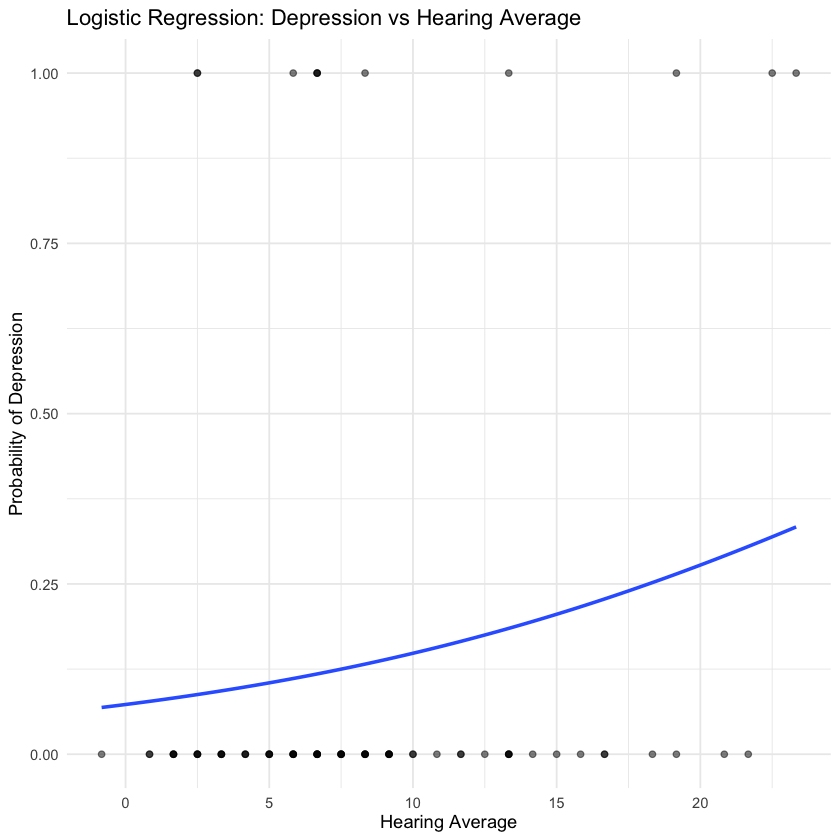

In [11]:
ggplot(selected_data, aes(x = hearing_avg, y = as.numeric(depression))) +
    geom_point(alpha = 0.5) +
    geom_smooth(method = "glm", method.args = list(family = "binomial"), se = FALSE) +
    labs(x = "Hearing Average", y = "Probability of Depression", title = "Logistic Regression: Depression vs Hearing Average") +
    theme_minimal()

## Odds Ratio

In logistic regression, the coefficients represent the change in the log-odds of the outcome for a one-unit increase in the predictor. To make this more interpretable, we often exponentiate the coefficients to get **odds ratios (OR)**.

- An OR of 1 means no change in odds
- An OR > 1 means increased odds of the outcome
- An OR < 1 means decreased odds of the outcome

For example, if the OR for hearing_avg is 1.5, it means that for every 1-unit increase in hearing average, the odds of depression increase by 50%.

In [10]:
# Compute odds ratios for the simple logistic regression model
exp(coef(model_dep_simple))

# Compute confidence intervals for the odds ratios
exp(confint(model_dep_simple))

(Intercept) hearing_avg 
 0.07875418  1.08250920

Waiting for profiling to be done...



,2.5 %,97.5 %
(Intercept),0.01962121,0.2526961
hearing_avg,0.97035272,1.2063263


## Controlling for Age

The relationship between hearing and depression might depend on age, as both hearing loss and depressive symptoms tend to increase with age. To properly assess the independent effect of hearing on depression, we should control for age in our model.

Create a new logistic regression model that includes both `hearing_avg` and `age` as predictors. Then, calculate the odds ratios for this adjusted model to see how the association changes after accounting for age.

In [ ]:
#YOUR CODE HERE